In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
clinical_path = "../data/raw/clinical/clinical.tsv"

clinical = pd.read_csv(clinical_path, sep="\t")

C:\Users\abrup\AppData\Local\Temp\ipykernel_25360\3758617340.py:3: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  clinical = pd.read_csv(clinical_path, sep="\t")


In [16]:
clinical.head()

,project.project_id,cases.case_id,cases.consent_type,cases.days_to_consent,cases.days_to_lost_to_followup,cases.disease_type,cases.index_date,cases.lost_to_followup,cases.primary_site,cases.submitter_id,...,treatments.treatment_duration,treatments.treatment_effect,treatments.treatment_effect_indicator,treatments.treatment_frequency,treatments.treatment_id,treatments.treatment_intent_type,treatments.treatment_or_therapy,treatments.treatment_outcome,treatments.treatment_outcome_duration,treatments.treatment_type
0,TCGA-BRCA,001cef41-ff86-4d3f-a140-a647ac4b10a1,Informed Consent,-34,'--,Ductal and Lobular Neoplasms,Diagnosis,'--,Breast,TCGA-E2-A1IU,...,'--,'--,'--,'--,1b884f21-eb24-467f-aba2-208af17070b9,Adjuvant,no,'--,'--,"Radiation Therapy, NOS"
1,TCGA-BRCA,001cef41-ff86-4d3f-a140-a647ac4b10a1,Informed Consent,-34,'--,Ductal and Lobular Neoplasms,Diagnosis,'--,Breast,TCGA-E2-A1IU,...,'--,'--,'--,'--,27868bc3-23c8-5e85-a0e2-314e6cdf9b2a,Adjuvant,yes,Treatment Ongoing,'--,Hormone Therapy
2,TCGA-BRCA,001cef41-ff86-4d3f-a140-a647ac4b10a1,Informed Consent,-34,'--,Ductal and Lobular Neoplasms,Diagnosis,'--,Breast,TCGA-E2-A1IU,...,'--,'--,'--,'--,aedf144c-6b7b-4d76-a3cb-4271aef10f1d,First-Line Therapy,yes,'--,'--,"Surgery, NOS"
3,TCGA-BRCA,0045349c-69d9-4306-a403-c9c1fa836644,Informed Consent,76,'--,Adenomas and Adenocarcinomas,Diagnosis,'--,Breast,TCGA-A1-A0SB,...,'--,'--,'--,'--,0a534cae-de91-5e77-a3e7-b52d46bd3966,First-Line Therapy,yes,'--,'--,"Surgery, NOS"
4,TCGA-BRCA,00807dae-9f4a-4fd1-aac2-82eb11bf2afb,Informed Consent,19,'--,Adnexal and Skin Appendage Neoplasms,Diagnosis,No,Breast,TCGA-A2-A04W,...,'--,'--,'--,'--,024faa94-ec57-4d14-b919-62dcab409958,Adjuvant,yes,Treatment Ongoing,'--,Bisphosphonate Therapy


In [17]:
clinical.columns


Index(['project.project_id', 'cases.case_id', 'cases.consent_type',
       'cases.days_to_consent', 'cases.days_to_lost_to_followup',
       'cases.disease_type', 'cases.index_date', 'cases.lost_to_followup',
       'cases.primary_site', 'cases.submitter_id',
       ...
       'treatments.treatment_duration', 'treatments.treatment_effect',
       'treatments.treatment_effect_indicator',
       'treatments.treatment_frequency', 'treatments.treatment_id',
       'treatments.treatment_intent_type', 'treatments.treatment_or_therapy',
       'treatments.treatment_outcome', 'treatments.treatment_outcome_duration',
       'treatments.treatment_type'],
      dtype='object', length=201)

In [18]:
clinical.shape

(5546, 201)

In [19]:
clinical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5546 entries, 0 to 5545
Columns: 201 entries, project.project_id to treatments.treatment_type
dtypes: object(201)
memory usage: 8.5+ MB


In [20]:
clinical.isnull().sum().sort_values(ascending=False).head(20)

project.project_id                                0
cases.case_id                                     0
cases.consent_type                                0
cases.days_to_consent                             0
cases.days_to_lost_to_followup                    0
cases.disease_type                                0
cases.index_date                                  0
cases.lost_to_followup                            0
cases.primary_site                                0
cases.submitter_id                                0
demographic.age_at_index                          0
demographic.age_is_obfuscated                     0
demographic.cause_of_death                        0
demographic.cause_of_death_source                 0
demographic.country_of_birth                      0
demographic.country_of_residence_at_enrollment    0
demographic.days_to_birth                         0
demographic.days_to_death                         0
demographic.demographic_id                        0
demographic.

In [21]:
[col for col in clinical.columns if "days" in col.lower()]

['cases.days_to_consent',
 'cases.days_to_lost_to_followup',
 'demographic.days_to_birth',
 'demographic.days_to_death',
 'diagnoses.days_to_best_overall_response',
 'diagnoses.days_to_diagnosis',
 'diagnoses.days_to_last_follow_up',
 'diagnoses.days_to_last_known_disease_status',
 'diagnoses.days_to_recurrence',
 'treatments.days_to_treatment_end',
 'treatments.days_to_treatment_start']

In [22]:
[col for col in clinical.columns if "vital" in col.lower()]

['demographic.vital_status']

In [23]:
[col for col in clinical.columns if "death" in col.lower()]

['demographic.cause_of_death',
 'demographic.cause_of_death_source',
 'demographic.days_to_death',
 'demographic.year_of_death']

In [24]:
[col for col in clinical.columns if "follow" in col.lower()]

['cases.days_to_lost_to_followup',
 'cases.lost_to_followup',
 'diagnoses.days_to_last_follow_up']

Create Survival Dataset   

so inorder to create a Survival Dataset we need 3 core pillers Patient ID,Time and Event 

In [ ]:
df = clinical.copy()

In [43]:
df["event"] = df["demographic.vital_status"].map({
    "Dead": 1,
    "Alive": 0
})

In [46]:
df["demographic.vital_status"]

0       Alive
1       Alive
2       Alive
3       Alive
4       Alive
        ...  
5541    Alive
5542    Alive
5543    Alive
5544    Alive
5545    Alive
Name: demographic.vital_status, Length: 5546, dtype: object

In [93]:
#status_count=df["demographic.vital_status"].value_counts()
#print(status_count)

In [57]:
df["time"] = df["demographic.days_to_death"]


0       '--
1       '--
2       '--
3       '--
4       '--
       ... 
5541    '--
5542    '--
5543    '--
5544    '--
5545    '--
Name: time, Length: 5546, dtype: object

In [ ]:
#status_count_time_death=df["demographic.days_to_death"].value_counts()
#print(status_count_time_death)

demographic.days_to_death
'--     4701
6593      40
548       33
912       22
1093      21
        ... 
3669       1
1          1
2207       1
1142       1
1927       1
Name: count, Length: 145, dtype: int64


"---  4701  rowsa has no data recorded .it is a censored data 

In [ ]:
#status_count_time_alive=df["diagnoses.days_to_last_follow_up"].value_counts()
#print(status_count_time_alive)

diagnoses.days_to_last_follow_up
'--       598
10.0       45
0.0        40
365.0      31
6593.0     28
         ... 
1694.0      1
811.0       1
2520.0      1
2273.0      1
2712.0      1
Name: count, Length: 827, dtype: int64


In [72]:
df["patient_id"]=df["demographic.submitter_id"]

In [73]:
df['death_days'] = pd.to_numeric(df['demographic.days_to_death'].replace("'--", np.nan), errors='coerce')

In [78]:

df['time'] = df['death_days'].fillna(pd.to_numeric(df['diagnoses.days_to_last_follow_up'].replace("'--", np.nan), errors='coerce'))

In [79]:

df['event'] = np.where(df['demographic.vital_status'] == 'Dead', 1, 0)

In [80]:
df['event'].value_counts()

event
0    4698
1     848
Name: count, dtype: int64

**Created a survival data frame from a messy clinical data**

In [95]:
survival_df = df[["patient_id", "time", "event"]]
survival_df = survival_df.dropna()
survival_df = survival_df.drop_duplicates(subset="patient_id")
survival_df = survival_df.reset_index(drop=True)
survival_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1097 entries, 0 to 1096
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   patient_id  1097 non-null   object 
 1   time        1097 non-null   float64
 2   event       1097 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 25.8+ KB


In [96]:
survival_df.value_counts()

patient_id                time    event
TCGA-3C-AAAU_demographic  4047.0  0        1
TCGA-3C-AALI_demographic  4005.0  0        1
TCGA-3C-AALJ_demographic  1474.0  0        1
TCGA-3C-AALK_demographic  1448.0  0        1
TCGA-4H-AAAK_demographic  348.0   0        1
                                          ..
TCGA-WT-AB44_demographic  883.0   0        1
TCGA-XX-A899_demographic  467.0   0        1
TCGA-XX-A89A_demographic  488.0   0        1
TCGA-Z7-A8R5_demographic  3287.0  0        1
TCGA-Z7-A8R6_demographic  3256.0  0        1
Name: count, Length: 1097, dtype: int64

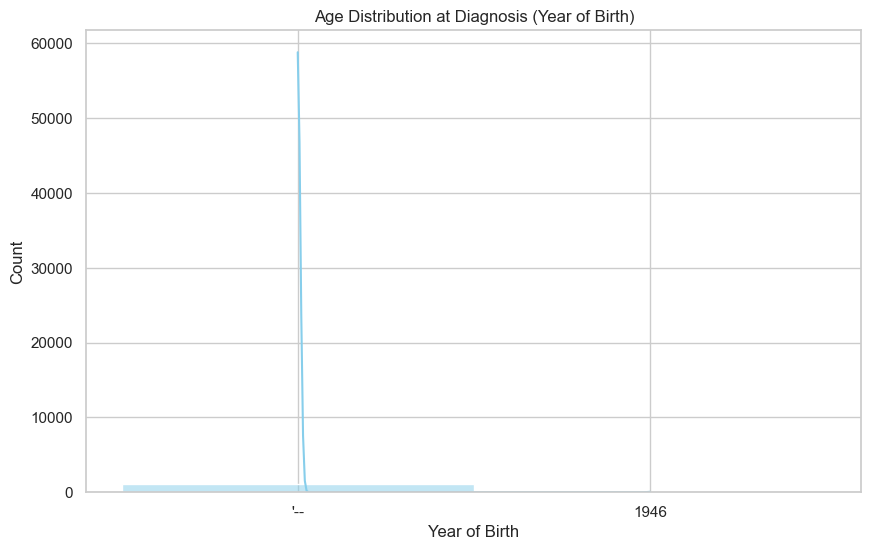

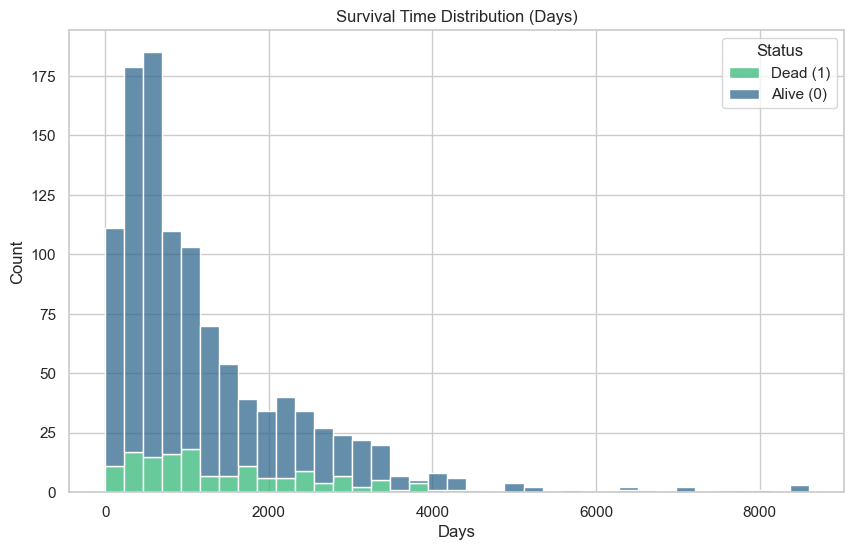

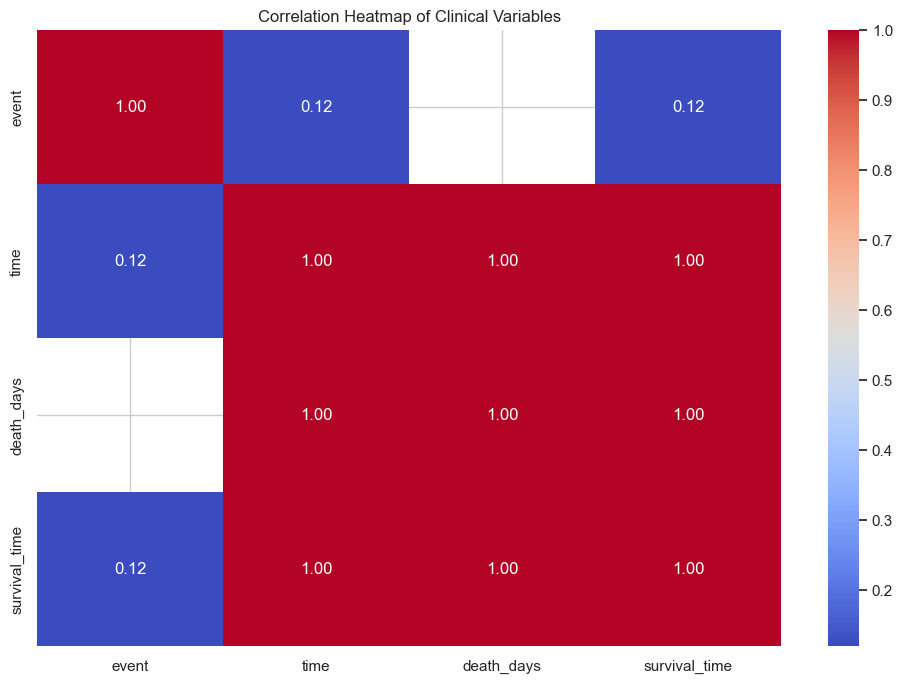

In [ ]:
# '

# # Set the visual style
# sns.set_theme(style="whitegrid")

# # --- 1. Age Distribution ---
# plt.figure(figsize=(10, 6))
# # Using the deduplicated data to count each person only once
# sns.histplot(df.drop_duplicates('patient_id')['demographic.year_of_birth'], kde=True, color='skyblue')
# plt.title('Age Distribution at Diagnosis (Year of Birth)')
# plt.xlabel('Year of Birth')
# plt.ylabel('Count')
# plt.savefig('age_distribution.png')
# # plt.show()

# # --- 2. Survival Time Histogram ---
# plt.figure(figsize=(10, 6))
# # We split by 'event' to see how long people lived vs. how long they were followed
# sns.histplot(data=survival_df, x='time', hue='event', multiple='stack', palette='viridis')
# plt.title('Survival Time Distribution (Days)')
# plt.legend(title='Status', labels=['Dead (1)', 'Alive (0)'])
# plt.xlabel('Days')
# plt.savefig('survival_histogram.png')
# plt.show()

# # --- 3. Correlation Heatmap ---
# plt.figure(figsize=(12, 8))
# # Selecting numeric columns only
# numeric_cols = df.select_dtypes(include=[np.number]).columns
# corr = df[numeric_cols].corr()
# sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
# plt.title('Correlation Heatmap of Clinical Variables')
# plt.savefig('correlation_heatmap.png')
# plt.show()

***Load Gene Expression Data***

In [32]:
import pandas as pd
import os

DATA_DIR = "../data/raw/genomic"
OUTPUT_FILE = "data/processed/gene_expression_matrix.csv"

os.makedirs("data/processed", exist_ok=True)

all_samples = []
files = [f for f in os.listdir(DATA_DIR) if f.endswith(".tsv")]

print(f"Files found: {len(files)}")

for file in files:
    path = os.path.join(DATA_DIR, file)

    df = pd.read_csv(path, sep="\t", comment='#')

    if "gene_name" in df.columns and "tpm_unstranded" in df.columns:

        # remove non-gene rows
        df = df[df["gene_name"].notna()]

        # select correct columns
        df = df[["gene_name", "tpm_unstranded"]]

        # group duplicates
        df = df.groupby("gene_name").sum()

        # patient ID
        patient_id = file.split(".")[0]

        # rename column
        df = df.rename(columns={"tpm_unstranded": patient_id})

        all_samples.append(df)

    else:
        print(f"⚠️ Skipping {file}: Missing columns")

# merge all patients
merged = pd.concat(all_samples, axis=1)

# transpose → patients as rows
merged = merged.T

Files found: 20


In [34]:
print("Shape:", merged.shape)

Shape: (20, 59428)


In [35]:
print(merged.index[:5])

Index(['03d891b3-8faf-4384-94ce-2015f1ca5df0',
       '28f1b708-bd3c-4ae7-935f-3282f75304a7',
       '2c1b1cbb-6e9f-4416-8faa-abb31d6b4e0e',
       '2dd0b954-db3e-402d-9c06-6160e199dedb',
       '36125e17-48fd-4eea-874c-ed2e2e218402'],
      dtype='object')


In [36]:
print(merged.columns[:10])

Index(['5S_rRNA', '5_8S_rRNA', '7SK', 'A1BG', 'A1BG-AS1', 'A1CF', 'A2M',
       'A2M-AS1', 'A2ML1', 'A2ML1-AS1'],
      dtype='object', name='gene_name')


In [37]:
print(merged.isna().sum().sum())

30918


In [38]:
merged.iloc[0, :10]

gene_name
5S_rRNA        0.3281
5_8S_rRNA      0.0000
7SK            0.2816
A1BG           0.0087
A1BG-AS1       0.0825
A1CF           0.0109
A2M          203.8892
A2M-AS1        1.9935
A2ML1          0.0292
A2ML1-AS1      0.0000
Name: 03d891b3-8faf-4384-94ce-2015f1ca5df0, dtype: float64

In [39]:
import requests
import json

file_ids = [f.split(".")[0] for f in files]

filters = {
    "op": "in",
    "content": {
        "field": "files.file_id",
        "value": file_ids
    }
}

params = {
    "filters": json.dumps(filters),
    "fields": "file_id,cases.submitter_id",
    "format": "JSON",
    "size": str(len(file_ids))
}

response = requests.get("https://api.gdc.cancer.gov/files", params=params)
data = response.json()["data"]["hits"]

mapping = {
    item["file_id"]: item["cases"][0]["submitter_id"]
    for item in data
}

In [48]:
# This will show you exactly what the API found
import pprint
pprint.pprint(mapping)

{}


In [51]:
all_samples = []

for file in files:
    # 1. Get the UUID (handle different naming conventions)
    # If your file is 'uuid.rna_seq.tsv', this gets 'uuid'
    file_uuid = file.split('.')[0] 
    
    path = os.path.join(DATA_DIR, file)
    df = pd.read_csv(path, sep="\t", comment='#')
    
    if "gene_name" in df.columns:
        # 2. Translate UUID to Patient ID
        # Check the mapping dictionary we built with the API
        patient_id = mapping.get(file_uuid)
        
        # If mapping didn't find it, we'll mark it as 'Unknown' to see the error
        if not patient_id:
            patient_id = f"NOT_FOUND_{file_uuid[:8]}"
            
        df = df[["gene_name", "unstranded"]]
        df = df.groupby("gene_name").sum()
        
        # 3. Use the Patient ID as the column name
        df = df.rename(columns={"unstranded": patient_id})
        all_samples.append(df)

merged_df = pd.concat(all_samples, axis=1)
print("New Columns:", merged_df.columns.tolist())

New Columns: ['NOT_FOUND_03d891b3', 'NOT_FOUND_28f1b708', 'NOT_FOUND_2c1b1cbb', 'NOT_FOUND_2dd0b954', 'NOT_FOUND_36125e17', 'NOT_FOUND_3f32cdec', 'NOT_FOUND_4c6cb929', 'NOT_FOUND_5cc4350c', 'NOT_FOUND_602e3d24', 'NOT_FOUND_6798cbfe', 'NOT_FOUND_7c9a2493', 'NOT_FOUND_94027f46', 'NOT_FOUND_9da89066', 'NOT_FOUND_a8e0466b', 'NOT_FOUND_c2e73efe', 'NOT_FOUND_c33ecc28', 'NOT_FOUND_df45fb41', 'NOT_FOUND_eb44c266', 'NOT_FOUND_f8ff90c6', 'NOT_FOUND_fb49b14e']
